# Convolutional Neural Network vs Random Forest

  ### 1. Import library

In [ ]:
import sys
import time
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

### 2. Environment & Device Check

In [2]:
print("Python exe:", sys.executable)
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Torch CUDA version:", torch.version.cuda)

USE_DEVICE = "cuda"   # options: "auto", "cpu", "cuda"

if USE_DEVICE == "cuda":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
elif USE_DEVICE == "cpu":
    device = torch.device("cpu")
else:  # auto
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Selected Mode : {USE_DEVICE}")
print(f"Using Device  : {device}")

if device.type == "cuda":
    print(f"GPU Name      : {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version  : {torch.version.cuda}")
else:
    print("Running on CPU")

Python exe: C:\Users\gusti\miniconda3\envs\mlenv\python.exe
Torch version: 2.6.0+cu124
CUDA available: True
Torch CUDA version: 12.4
Selected Mode : cuda
Using Device  : cuda
GPU Name      : NVIDIA GeForce RTX 3050 6GB Laptop GPU
CUDA Version  : 12.4


### 3. Dataset Loading & Preprocessing

In [3]:
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=train_transform
)

testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=test_transform
)

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=32,
    shuffle=True,
    num_workers=0
)

testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=128,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

classes = trainset.classes

print("data train:", len(trainset))
print("data test :", len(testset))
print("Classes:", classes)

C:\Users\gusti\miniconda3\envs\mlenv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


data train: 50000
data test : 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


### 4. Data Visualization (Sample Images)

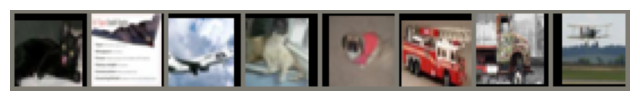

['cat', 'airplane', 'airplane', 'cat', 'dog', 'truck', 'truck', 'airplane']


In [4]:
def imshow(img):
    # CIFAR-10 mean & std
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    std  = torch.tensor([0.2023, 0.1994, 0.2010]).view(3, 1, 1)

    img = img * std + mean   # unnormalize 
    img = img.clamp(0, 1)   

    npimg = img.numpy()
    plt.figure(figsize=(8, 4))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis("off")
    plt.show()

dataiter = iter(trainloader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images[:8]))
print([classes[labels[i]] for i in range(8)])

### 5. CNN Model Initialization

In [5]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(64 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # 32x32 -> 16x16
        x = self.pool(F.relu(self.conv2(x)))   # 16x16 -> 8x8
        x = x.view(x.size(0), -1)              # flatten
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = SimpleCNN().to(device)
print(model)

SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4096, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=10, bias=True)
)


### 6. Loss Function & Optimizer

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

### 7. Training CNN

In [7]:
num_epochs = 80
train_losses = []
epoch_times = []

train_start_time = time.time()

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    epoch_start = time.time()

    loop = tqdm(trainloader, desc=f"Epoch [{epoch+1}/{num_epochs}]", leave=True)

    for inputs, labels in loop:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    epoch_loss = running_loss / len(trainloader)
    train_losses.append(epoch_loss)

    epoch_time = time.time() - epoch_start
    epoch_times.append(epoch_time)

    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss:.4f} - Time: {epoch_time:.2f} sec")

total_train_time = time.time() - train_start_time
print(f"\nTotal Training Time: {total_train_time:.2f} sec")

Epoch [1/80]: 100%|████████████████████████████████████████████████████| 1563/1563 [00:47<00:00, 32.81it/s, loss=0.695]


Epoch 1/80 - Loss: 1.4632 - Time: 47.64 sec


Epoch [2/80]: 100%|████████████████████████████████████████████████████| 1563/1563 [00:47<00:00, 32.82it/s, loss=0.689]


Epoch 2/80 - Loss: 1.1253 - Time: 47.63 sec


Epoch [3/80]: 100%|█████████████████████████████████████████████████████| 1563/1563 [00:47<00:00, 32.80it/s, loss=1.22]


...

Epoch 78/80 - Loss: 0.4293 - Time: 50.74 sec


Epoch [79/80]: 100%|███████████████████████████████████████████████████| 1563/1563 [00:51<00:00, 30.27it/s, loss=0.691]


Epoch 79/80 - Loss: 0.4278 - Time: 51.64 sec


Epoch [80/80]: 100%|████████████████████████████████████████████████████| 1563/1563 [00:51<00:00, 30.23it/s, loss=0.83]

Epoch 80/80 - Loss: 0.4275 - Time: 51.71 sec

Total Training Time: 4056.34 sec


### 8. Training Performance Visualization

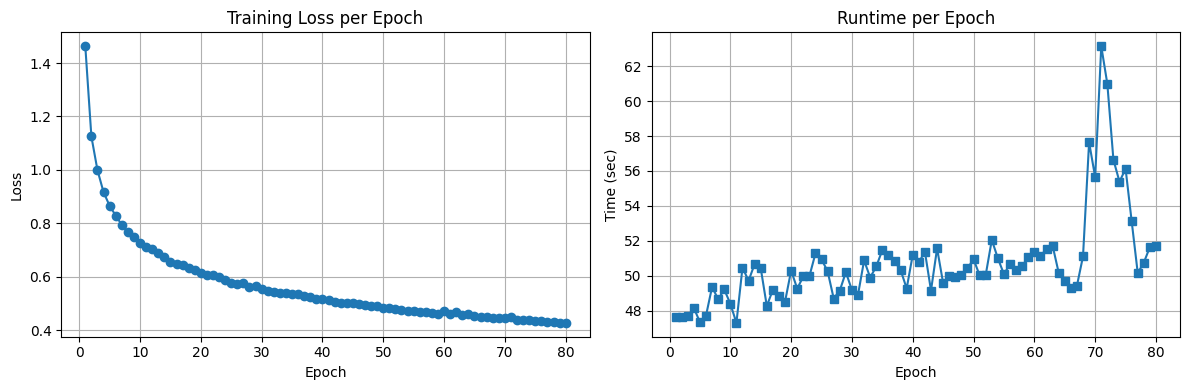

In [8]:
plt.figure(figsize=(12, 4))

epochs = range(1, num_epochs + 1)

# Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss per Epoch")
plt.grid(True)

# Runtime
plt.subplot(1, 2, 2)
plt.plot(epochs, epoch_times, marker='s')
plt.xlabel("Epoch")
plt.ylabel("Time (sec)")
plt.title("Runtime per Epoch")
plt.grid(True)

plt.tight_layout()
plt.show()

### 9. CNN Model Evaluation

In [9]:
model.eval()
correct = 0
total = 0

test_start_time = time.time()

with torch.no_grad():
    for images, labels in tqdm(testloader, desc="Testing"):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

total_test_time = time.time() - test_start_time
accuracy = 100 * correct / total

print("=== MODEL EVALUATION ===")
print(f"Device              : {device}")
print(f"Epochs              : {num_epochs}")
print(f"Final Train Loss    : {train_losses[-1]:.4f}")
print(f"Test Accuracy       : {accuracy:.2f}%")
print(f"Total Training Time : {total_train_time:.2f} sec")
print(f"Total Testing Time  : {total_test_time:.2f} sec")
print(f"Avg Epoch Time      : {sum(epoch_times)/len(epoch_times):.2f} sec")
print(f"Avg Time per Sample : {total_test_time / total:.6f} sec")

Testing: 100%|█████████████████████████████████████████████████████████████████████████| 79/79 [00:07<00:00, 11.09it/s]

=== MODEL EVALUATION ===
Device              : cuda
Epochs              : 80
Final Train Loss    : 0.4275
Test Accuracy       : 79.93%
Total Training Time : 4056.34 sec
Total Testing Time  : 7.13 sec
Avg Epoch Time      : 50.70 sec
Avg Time per Sample : 0.000713 sec


### 10. Inference Result Visualization

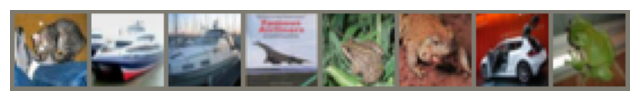

Predicted: ['cat', 'ship', 'ship', 'airplane', 'frog', 'frog', 'airplane', 'deer']
Actual   : ['cat', 'ship', 'ship', 'airplane', 'frog', 'frog', 'automobile', 'frog']


In [10]:
model.eval()

dataiter = iter(testloader)
images, labels = next(dataiter)

images_device = images.to(device)
labels_device = labels.to(device)

with torch.no_grad():
    outputs = model(images_device)
    _, predicted = torch.max(outputs, 1)

images_cpu = images[:8]
predicted_cpu = predicted[:8].cpu()
labels_cpu = labels[:8]

imshow(torchvision.utils.make_grid(images_cpu))

print("Predicted:", [classes[predicted_cpu[i]] for i in range(8)])
print("Actual   :", [classes[labels_cpu[i]] for i in range(8)])

## Random Forest

### 1. Get Data

In [11]:
X_train = trainset.data
y_train = np.array(trainset.targets)

X_test = testset.data
y_test = np.array(testset.targets)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


### 2. Preprocessing

In [12]:
X_train = X_train.reshape(len(X_train), -1).astype(np.float32) / 255.0
X_test = X_test.reshape(len(X_test), -1).astype(np.float32) / 255.0

print("Train shape after reshape:", X_train.shape)
print("Test shape after reshape :", X_test.shape)

Train shape after reshape: (50000, 3072)
Test shape after reshape : (10000, 3072)


### 3. Get Subset Data

In [13]:
TRAIN_SAMPLES = 50000
TEST_SAMPLES = 10000

X_train_small = X_train[:TRAIN_SAMPLES]
y_train_small = y_train[:TRAIN_SAMPLES]

X_test_small = X_test[:TEST_SAMPLES]
y_test_small = y_test[:TEST_SAMPLES]

print("Train data:", len(X_train_small))
print("Test data:", len(X_test_small))

Train data: 50000
Test data: 10000


### 4. Initiate RF Model

In [14]:
N_ESTIMATORS = 100
MAX_DEPTH = None
RANDOM_STATE = 42

rf = RandomForestClassifier(
    n_estimators=N_ESTIMATORS,
    max_depth=MAX_DEPTH,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print("Random Forest model succesfully created")

Random Forest model succesfully created


### 5. Training RF

In [15]:
print("Training Random Forest...")

train_start = time.perf_counter()
rf.fit(X_train_small, y_train_small)
train_time = time.perf_counter() - train_start

print(f"Training finished in {train_time:.2f} sec")

Training Random Forest...
Training finished in 41.25 sec


### 6. Prediction

In [16]:
BATCH_SIZE = 200
y_pred_list = []

print("Predicting...")
test_start = time.perf_counter()

for i in tqdm(range(0, len(X_test_small), BATCH_SIZE)):
    batch = X_test_small[i:i+BATCH_SIZE]
    preds = rf.predict(batch)
    y_pred_list.append(preds)

y_pred = np.concatenate(y_pred_list)

test_time = time.perf_counter() - test_start

print(f"Testing finished in {test_time:.2f} sec")

Predicting...


100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [00:03<00:00, 14.05it/s]

Testing finished in 3.56 sec


### 7. RF Evaluation

In [17]:
accuracy = accuracy_score(y_test_small, y_pred)

print("\n===== RANDOM FOREST EVALUATION RESULTS =====")
print(f"Number of Trees  : {N_ESTIMATORS}")
print(f"Max Depth        : {MAX_DEPTH}")
print(f"Accuracy         : {accuracy * 100:.2f}%")
print(f"Train Time       : {train_time:.2f} sec")
print(f"Test Time        : {test_time:.2f} sec")
print(f"Avg Time/Sample  : {test_time / len(y_test_small):.6f} sec")


===== RANDOM FOREST EVALUATION RESULTS =====
Number of Trees  : 100
Max Depth        : None
Accuracy         : 46.54%
Train Time       : 41.25 sec
Test Time        : 3.56 sec
Avg Time/Sample  : 0.000356 sec
